**Agent Based Model of Secondary Critical Materials Market Development Around Solar PV Recovery**

Abheek Chatterjee(1,2) and Nehika Mathur(1)

1-Systems Integration Division, Naitonal Institute of Standards and Technology, Gaithersburg, MD                              
2-College of Computer, Mathematical and Natural Sciences, University of Maryland, College Park, MD

In [ ]:
#Installing Mesa Library
#Please note that since this code was developed - The Mesa Library was updated
#To use the code in the curent form please install the version listed below
!pip install mesa==2.4.0

In [1]:
#Import libraries
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import json
from scipy import stats
import copy

**Model Parameters:**

<u>Number of model steps:</u>   
Each step in the model represents a year
Step 0 set for year 2020   
End year of model run = 2020 + (N_steps-1)   
Currently set to simulate 2020-2050

<u>EoU PV projection:</u>     
Curve fiting based on data available from Weckend, S., Wade, A., and Heath, G. A. (2016). End of life management: Solar photovoltaic panels. Technical report, International Renewable Energy Agency.      
Followed by using the cumulative data differences to estimate annual PV waste amounts     
Code in: EoU_PV_Estimation_and_plot.py   
3 levels of waste projections: (a) Lower-end estimate: Regular loss projections, (b) Higher-end estimate: Early loss projections, (c) Average estimate
Case study base on Arizona - which has approximately 4.5% of US PV installations (based on https://www.seia.org/states-map)

<u>Material demand projections:</u>        
2030 Demand numbers from Mathur, N., Sutherland, J., and Singh, S. (2022). A study on end of life photovoltaics as a model for developing industrial synergistic networks. Journal of Remanufacturing, 12(2):281–301.   
Cumulative annual growth rate (CAGR) obtained from online reports   
Demand is estimated assuming constant CAGR

<u>Material costs, shipping cost, and landfill costs:</u>     
Based on the information obtained from: Mathur, N., Sutherland, J., and Singh, S. (2022). A study on end of life photovoltaics as a model for developing industrial synergistic networks. Journal of Remanufacturing, 12(2):281–301, and Walzberg, J., Carpenter, A., and Heath, G. A. (2021). Role of the social factors in success of solar photovoltaic reuse and recycle programmes. Nature Energy, 6(9):913–924.                           


<u>PV recovery process parameters:</u>                               
Estimated costs of PV recycling process obtained from two sources: Cui, H., Heath, G., Remo, T., Ravikumar, D., Silverman, T., Deceglie, M., ... & Engel-Cox, J. (2022). Technoeconomic analysis of high-value, crystalline silicon photovoltaic module recycling processes. Solar Energy Materials and Solar Cells, 238, 111592, and Deng, R., Chang, N. L., Ouyang, Z., & Chong, C. M. (2019). A techno-economic review of silicon photovoltaic module recycling. Renewable and Sustainable Energy Reviews, 109, 532-550.                                     
Three scenarios of average recovery cost reductions were tested: (a) 2.5\% per year (slow reduction rate), (b) 5\% per year (moderate reduction rate, base condition), and (c) 7.5\% per year (fast reduction rate). The projected PV recovery cost reduction is limited to 500 USD per ton based on the references.                           
FRELP process yields of different materials obtained from - Latunussa, C. E., Ardente, F., Blengini, G. A., & Mancini, L. (2016). Life Cycle Assessment of an innovative recycling process for crystalline silicon photovoltaic panels. Solar energy materials and solar cells, 156, 101-111.

<u>PV decommissioning firm parameters:</u>                              
PV decomissioning firm storage: Warehouse usable volume - estimated based on EIA provided average warehouse size in USA - 17400 sq ft. (~1616.5 m^2) and assuming 30ft (9 m) height (https://www.eia.gov/consumption/commercial/pba/warehouse-and-storage.php). Space requirements for storing different materials/used PVs estimated based on material densities and PV panel geometry and weight provided in Walzberg, J., Carpenter, A., and Heath, G. A. (2021). Role of the social factors in success of solar photovoltaic reuse and recycle programmes. Nature Energy, 6(9):913–924.               
Decommissioning firm's initial trust rating (probability of forming business partnerships) of co-located manufacturing firms is set as 0.75 - to model a high initial willingness to participate in secondary materials partnerships as they would be the driver of its recovery operations. Initial expected demand for secondary material is based on prevalance of use of secondary resources in varial materials market reports.

<u> Co-located manufacturing firms' parameters:</u>                
Secondary material confidence ratings indicate the fraction of demand a manufacturing firm is willing to meet usinf secondary materials. This confidence rating increases upon successful secondary material exhcnages. Initial secondary material confidence is set based on available industry reports and discussion with experts. Each firm also has a contraint on the maximum fraction of demand that can be met via secondary materials. Currently, it is assumed that all demand can be replaced by secondary materials, if possible. The co-located manufacturing firms also have a opportunistic behavior tendency parameter - the probability that they will chose not to share costs of the material exchange with the supplier to incrase short-term profit margins. In the base scenario, it is set low (Probability of opportunistic behavior = 0.1) for all co-located manufacturing firms to model predominantly collaborative cost-sharing behavior by partner firms. When firms act collaboratively (instead of opportunistically) regarding cost-sharing, they are willing to share costs up to a threshold - which is the maximum perectnage of savings (from sourcing secondary material instead of virgin materials), which the firm is willing to spend to build stable partnerships to generate long-term profits and secure alternative resource supply pathways. It is currently set to 20%.

<u>Firm locations and distances:</u>                                                          
The region of interest is modeled as a cartesian grid. The PV decomissioning firm is placed at the center. The distance of manufacturing firms and landfill is obatined from the case study in Mathur, N., Sutherland, J., and Singh, S. (2022). A study on end of life photovoltaics as a model for developing industrial synergistic networks. Journal of Remanufacturing, 12(2):281–301.

<u>Environmental impact assessment parameters:</u>                              
Obatained from the Ecoinvent - 3 database.

In [2]:
#1. Number of model steps
N_steps = 31

#2. EoU PV projection
#Data storage updated 9/10/2026
#loading EoU PV Data for hypothetical test region
#Dictionary keys:
 #(a)-1: Regular Loss Scenario
 #(b) 0: Average Scenario
 #(c)Early Loss Scenatio
with open("eou_pv_data.json", "r", encoding="utf-8") as f:
    eou_pv = json.load(f)

#3. Material demands
demand_0 = {"Al": 1710,
            "G":  3500,
            "Cu":  50,
            "Si": 390,
            "Ag": 10} #Unit - metric tons
demand_growth_rate = {"Al": 2.4,
                       "G":  7.5,
                       "Cu":  6.5,
                       "Si": 2.8,
                       "Ag": 7} #Percentage
materials = ['Al','G','Cu','Si','Ag']
demand_proj = {}
for m in materials:
    dem_array = np.zeros(N_steps)
    dem_array[0] = demand_0[m]
    for i in range(1,N_steps):
            dem_array[i] = dem_array[i-1]*(1+(demand_growth_rate[m]/100))
    demand_proj[m] = dem_array

#4. Material Costs
#Virgin materials
v_cost_b = {"Al": 2200,
            "G":  55,
            "Cu": 5850,
            "Si": 3000,
            "Ag": 600000} #Base cost - USD/metric ton
v_cost_h = {"Al": 2510,
            "G":  70,
            "Cu": 7500,
            "Si": 3180,
            "Ag": 653000} #Upper limit cost - disruption scenario - USD/metric ton
v_cost_norm = {"Al": [2200]*N_steps,
            "G":  [55]*N_steps,
            "Cu": [5850]*N_steps,
            "Si": [3000]*N_steps,
            "Ag": [600000]*N_steps} #USD/metric ton
#Scondary materials
r_cost_b = {"Al": 1470, #60% of virgin material cost
            "G":  35,
            "Cu":  5260,
            "Si": 2690,
            "Ag": 553000} #Base cost - USD/metric ton
r_cost_h = {"Al": 1980,
            "G":  60,
            "Cu": 6750,
            "Si": 3000,
            "Ag": 600000} #Upper limit cost - disruption scenario - USD/metric ton
r_cost_norm = {"Al": [1470]*N_steps,
            "G":  [35]*N_steps,
            "Cu":  [5260]*N_steps,
            "Si": [2690]*N_steps,
            "Ag": [553000]*N_steps} #USD/metric ton

#5. Shipping cost, landfill costs, and landfill distance
ship_cost = 3 #usd/ton-km
lf_cost_pv = 100 #usd/ton
lf_cost_mat = 50 #usd/ton
lf_dist = 50 #km

#6. PV recovery parameters - cost and required PV recycling for unit material recovery
rec_cost_b = [0]*N_steps
rec_cost_b[0] = 1500
for i in range(1,N_steps):
    rec_cost_b[i] = max(500, 0.95*rec_cost_b[i-1]) #USD/ton
rec_cost_f = [0]*N_steps
rec_cost_f[0] = 1500
for i in range(1,N_steps):
    rec_cost_f[i] = max(500, 0.925*rec_cost_f[i-1]) #USD/ton
rec_cost_s = [0]*N_steps
rec_cost_s[0] = 1500
for i in range(1,N_steps):
    rec_cost_s[i] = max(500, 0.975*rec_cost_s[i-1]) #USD/ton

req_pv_rec_unit_mat = {'Al': 5.47,
                        'G': 1.46,
                        'Cu': 228.31,
                        'Si': 28.84,
                        'Ag': 2000} #ton PV/ton material


#7. PV decommissioning firm storage/inventory parameters
usable_inv_vol = 15000 #m3
stor_vol_req = {'Al': 0.369,
                'Cu': 0.112,
                'Si': 0.429,
                'Ag': 0.095,
                'PV': 3.16} #m3/ton

#8. Initial PV firm's trust ratings of co-located manufacturing firms and expected secondary materials demand
pv_firm_trust_ratings0 = {'Al': 0.75,
                          'G': 0.75,
                          'Cu': 0.75,
                          'Si': 0.75,
                          'Ag': 0.75}
expected_demand0 = {'Al': round((demand_0['Al']*0.5)),
                    'G': round((demand_0['G']*0.2)),
                    'Cu': round((demand_0['Cu']*0.2)),
                    'Si': round((demand_0['Si']*0.2)),
                    'Ag': round((demand_0['Ag']*0.2))}

#9. Manufacturing firms secondary material confidence, use limits
sec_material_use0 = {'Al': 0.5,
                          'G': 0.2,
                          'Cu': 0.2,
                          'Si': 0.2,
                          'Ag': 0.2}
sec_mat_use_limit = {'Al': 1,
                     'G': 1,
                     'Cu': 1,
                     'Si': 1,
                     'Ag': 1}

#10. Cost-sharing parameters: threshold cost-share percentage and oppurtunitistic behavior probability
threshold_percentage = {'Al': 0.2,
                        'G': 0.2,
                        'Cu': 0.2,
                        'Si': 0.2,
                        'Ag': 0.2}
opp_behavior_probability = {'Al': 0.1,
                            'G': 0.1,
                            'Cu': 0.1,
                            'Si': 0.1,
                            'Ag': 0.1}

#11. Firm locations and distances
boundary_len = 75 #km
pv_pos = (int(boundary_len/2), int(boundary_len/2)) #PV decom firm fixed at center of simulation region
al_pos = (int(boundary_len/2), int(boundary_len/2)+15) #Al firm distance to PV decom firm ~15 km
cu_pos = (int(boundary_len/2)+13, int(boundary_len/2)) #Cu firm distance to PV decom firm ~13 km
si_pos = (int(boundary_len/2), int(boundary_len/2)-16) #Si firm distance to PV decom firm ~16 km
ag_pos = (int(boundary_len/2)-21, int(boundary_len/2)) #Ag firm distance to PV decom firm ~21 km
g_pos = (int(boundary_len/2)-9, int(boundary_len/2)-9) #G firm distance to PV decom firm ~12.6 km
agent_pos = {'Al': al_pos,
                   'G': g_pos,
                   'Cu': cu_pos,
                   'Si': si_pos,
                   'Ag': ag_pos,
                   'PV': pv_pos}
lf_dist = 50 #km

#12. Virgin Material Supply
vir_mat_supply_norm = {}
for m in materials:
    vir_mat_supply_norm[m] = [d*5 for d in demand_proj[m]]
    #Demand is multiplied by 5 to model that under normal conditions the virgin material supply is in excess of requirements
    #The multiplier (5) is chosen arbitrarily

**PV Decommissioning Firm Agent**   
It has a certain availability of EoU PVs each year   
It has to decide what fraction of EoU PVs to:   
    1. Recover material from   
    2. Landfill   

In [3]:
class PV_Decom(mesa.Agent):
    def __init__(self, unique_id, model, pos, eou_pv,
                 trust_ratings, expected_demand,
                 pv_rec_cost, req_pv_rec_unit_mat,
                 inv_vol, req_stor_vol,
                 new_mat_costs, rec_mat_costs, delivery_cost,
                 landfill_cost_pv, landfill_cost_mat, landfill_dist,
                 tot_model_steps):

        ###### COMMON AGENT PARAMETERS (FROM MODEL) #######
        super().__init__(unique_id, model)
        self.unique_id = unique_id
        self.type = 'PV'
        self.pos = pos
        self.new_mat_costs = new_mat_costs
        self.rec_mat_costs = rec_mat_costs
        self.delivery_cost = delivery_cost
        self.lf_cost_pv = landfill_cost_pv
        self.lf_cost_mat = landfill_cost_mat
        self.lf_dist = landfill_dist

        ####### UNIQUE AGENT PARAMETERS #######

        ## EoU_PV availability
        self.eou_pv = eou_pv
        ## Trust in co-located manufacturing firms
        self.trust = trust_ratings
        ## Initialize expected demand for resources at step 0
        self.expected_demand = expected_demand
        ## Distance to Mfg firms
        #Initialize at 0
        #set actal numbers when initailizing model class after mfg firms have been placed on the grid
        self.firm_distances = {'Al': 0,
                               'G': 0,
                               'Cu': 0,
                               'Si': 0,
                               'Ag': 0}
        #Required PV recovery to get unit material of interest
        self.req_PV_recovery_unit = req_pv_rec_unit_mat
        #PV recovery cost
        self.pv_recovery_cost = pv_rec_cost
        #Required storage volumes
        self.req_stor_vol = req_stor_vol

        ####### RECORD OF AGENT ACTIONS/INTERACTIONS #######

        ## Partnership records
        #(A) Material exchange record
        #sent to each co-located firm (tons of specific material) at each time step
        #Information updated after each negotiation - if no negotiation - no partnership to record
        self.partnership_record = {'Al': np.zeros(tot_model_steps),
                                   'G': np.zeros(tot_model_steps),
                                   'Cu': np.zeros(tot_model_steps),
                                   'Si': np.zeros(tot_model_steps),
                                   'Ag': np.zeros(tot_model_steps)}
        #(B) Firm Behavior record
        #Cost-sharing behavior of co-located firms
        #0 - no offer, 1 - collaborative, -1 - opportunistic
        self.behavior_record = {'Al': np.zeros(tot_model_steps),
                                   'G': np.zeros(tot_model_steps),
                                   'Cu': np.zeros(tot_model_steps),
                                   'Si': np.zeros(tot_model_steps),
                                   'Ag': np.zeros(tot_model_steps)}
        #(C) Order record
        #Order by each firm at each time step - regardless of final decision
        #Orders saved regardless as they help in updating expected demand
        self.order_record = {'Al': np.zeros(tot_model_steps),
                            'G': np.zeros(tot_model_steps),
                            'Cu': np.zeros(tot_model_steps),
                            'Si': np.zeros(tot_model_steps),
                            'Ag': np.zeros(tot_model_steps)}
        ## PV recovery records
        #Amount of solar PVs recovered at each time step
        self.EoU_PV_recovery = np.zeros(tot_model_steps)
        ## Landfilling records
        #Amount of used PVs or recovered materials landfilled
        self.mat_lf_record = {'Al': np.zeros(tot_model_steps),
                            'G': np.zeros(tot_model_steps),
                            'Cu': np.zeros(tot_model_steps),
                            'Si': np.zeros(tot_model_steps),
                            'Ag': np.zeros(tot_model_steps),
                            'PV': np.zeros(tot_model_steps)}
        ##Inventory records
        #Amount of used PVs/materials kept in inventory at the end of each step
        #No storage of Glass - low value high space consumption
        self.inventory_record = {'Al': np.zeros(tot_model_steps),
                                'Cu': np.zeros(tot_model_steps),
                                'Si': np.zeros(tot_model_steps),
                                'Ag': np.zeros(tot_model_steps),
                                'PV': np.zeros(tot_model_steps)}
        ## Total inventory volume
        self.inv_vol = inv_vol
        ## Use of PV stored in Inventory records
        self.pv_inventory_use_record = np.zeros(tot_model_steps)
        ## PV addition to inventory (annual) records
        self.pv_inventory_add_record = np.zeros(tot_model_steps)

        ####### AGENT CURRENT STEP INFORMATION #######
        #These attributes are updated in each step

        ## Current step unused recovered materials
        #set as existing inventory from last step at the begining of each step
        self.current_unused_rec = {'Al': 0,
                                   'G': 0,
                                   'Cu': 0,
                                   'Si': 0,
                                   'Ag': 0}
        ## Cost-share amounts for current step
        #set as 1 at the begining of each step
        self.current_cost_share = {'Al': 1,
                               'G': 1,
                               'Cu': 1,
                               'Si': 1,
                               'Ag': 1}
        ## Current step order records
        #Initialized as None - signifying no interaction (yet)
        #0 - Firm chose not to place order
        #1 - Firm placed order - and was accepted
        #-1 - Firm placed order and was rejected
        self.curr_orders = {'Al': None,
                            'G': None,
                            'Cu': None,
                            'Si': None,
                            'Ag': None}
        ## Currently available EoU PVs
        #set as new avl PV + inventory PV from last step - at the beginning of each step
        self.curr_avl_pv = 0
        ## Current available inventory space
        #Variable simply initiated here at 0
        #Actual current step inventory availability calculated based on previous steps inventory record at the beginning og each step
        self.curr_avl_inv = 0

    def reset_current_state(self, step):
        #function to reset current step attributes at the start of a step
        #Unused recovered materials
        if step > 0:
            #Note - no inventory for glass
            self.current_unused_rec = {'Al': self.inventory_record['Al'][step-1],
                                       'G': 0,
                                       'Cu': self.inventory_record['Cu'][step-1],
                                       'Si': self.inventory_record['Si'][step-1],
                                       'Ag': self.inventory_record['Ag'][step-1]}
        else:
            self.current_unused_rec = {'Al': 0,
                                       'G': 0,
                                       'Cu': 0,
                                       'Si': 0,
                                       'Ag': 0}
        #Cost shares
        self.current_cost_share = {'Al': 1,
                               'G': 1,
                               'Cu': 1,
                               'Si': 1,
                               'Ag': 1}
        #Current orders
        self.curr_orders = {'Al': None,
                            'G': None,
                            'Cu': None,
                            'Si': None,
                            'Ag': None}
        #Current available EoU PVs
        if step == 0:
            self.curr_avl_pv = self.eou_pv[step]
        else:
            self.curr_avl_pv = self.eou_pv[step] + self.inventory_record['PV'][step-1]

        #Current available inventory
        if step > 0:
            mat = ['PV', 'Al', 'Cu', 'Si', 'Ag'] #Glass is not considered valuable enough to store
            total_used_vol = 0
            for m in mat:
                used_vol_m = self.inventory_record[m][step-1]*self.req_stor_vol[m]
                total_used_vol += used_vol_m
            self.curr_avl_inv = self.inv_vol - total_used_vol
        else:
            self.curr_avl_inv = self.inv_vol

    def update_curr_state_post_negotiation(self, firm, decision,
                                           add_eou_pv_rec, add_unused_mats, cost_share_param):
        #Function to update current step attributes after each negoatiation
        ## Update current order record
        self.curr_orders[firm] = decision
        ## Update cost-share
        if decision == 1: #if partnership accepted
            self.current_cost_share[firm] = cost_share_param
        else: #ether rejected or no offer made my mfg firm
            #cost-share for that firm is set as 0
            self.current_cost_share[firm] = 0
        ## Update avl EoU PVs
        self.curr_avl_pv -= add_eou_pv_rec
        ## Update unused material amounts
        mat = ['Al', 'G', 'Cu', 'Si', 'Ag']
        if add_unused_mats == None:
            for m in mat:
                self.current_unused_rec[m] += 0 #no additional materials to add
        else:
            for m in mat:
                self.current_unused_rec[m] += add_unused_mats[m]

    def record_mfg_firm_distances(self,distances):
        firms = ['Al', 'G', 'Cu', 'Si', 'Ag']
        for f in firms:
            self.firm_distances[f] = distances[f]

    def update_trust_based_interaction_prob(self, sharing_offer_strategy, firm, step):
        #first update behavior record
        self.behavior_record[firm][step] = sharing_offer_strategy
        #Evaluate recent interactions
        if step == 0:
            x = (self.behavior_record[firm][step])
        if step == 1:
            x = (self.behavior_record[firm][step] + self.behavior_record[firm][step-1])
        if step >= 2:
            x = (self.behavior_record[firm][step] + self.behavior_record[firm][step-1] + self.behavior_record[firm][step-2])
        #Use logistic function (with rounding) to determine probability of partnering given recent interaction history
        k = 1
        x0 = -1
        p = 1/(1+math.exp(-k*(x-x0)))
        round_factor = 0.05
        q = p//round_factor
        r = p%round_factor
        if r >= round_factor/2:
            res = round_factor*(q+1)
        else:
            res = round_factor*q
        #Update trust for partnership with firm
        self.trust[firm] = res

    def decide_to_negotiate(self, firm):
        r = random.random()
        if r<= self.trust[firm]:
            return 1
        else:
            return -1

    def update_expected_demand(self,step):
        #Updates are based on last three (or known history) orders - at the start of each time step
        #Regardless of whether they were accepted or not
        #Has to be done for all recovered resource types
        mat = ['Al', 'G', 'Cu', 'Si', 'Ag']

        if step == 0:
            pass #nothing to update
        elif step == 1:
            for m in mat:
                x = np.array([-1,0])
                #avg(Initial expected demand, step 0 order)
                y = np.array([self.expected_demand[m], self.order_record[m][0]])
                res = stats.linregress(x, y)
                pred_demand = res.intercept + res.slope*step
                self.expected_demand[m] = max(0,pred_demand)
        elif step == 2:
            for m in mat:
                x = np.array([0,1])
                #avg(Initial expected demand, step 0 order)
                y = np.array([self.order_record[m][0], self.order_record[m][1]])
                res = stats.linregress(x, y)
                pred_demand = res.intercept + res.slope*step
                self.expected_demand[m] = max(0,pred_demand)
        else:
            for m in mat:
                x = np.array([step-3,step-2,step-1])
                #(Initial expected demand, step 0 order, step 1 order)
                y = np.array([self.order_record[m][step-3], self.order_record[m][step-2], self.order_record[m][step-1]])
                res = stats.linregress(x, y)
                pred_demand = res.intercept + res.slope*step
                self.expected_demand[m] = max(0,pred_demand)

    def evaluate_order(self, firm, order_amount, cost_share_offer, step):

        type = firm
        unused_mat_avl = self.current_unused_rec[type]
        amount_ordered = order_amount
        self.current_cost_share[type] = cost_share_offer

        # Step 1: Check if any unused recovered material available from other accepted orders
        if unused_mat_avl == 0:
            accepted_amount = 0
            rem_order_amount = amount_ordered
            #no change in unused recovered material of current order type

        elif unused_mat_avl > amount_ordered:
            accepted_amount = amount_ordered
            rem_order_amount = 0
            self.current_unused_rec[type] = unused_mat_avl - amount_ordered

        elif amount_ordered > unused_mat_avl:
            accepted_amount = unused_mat_avl
            rem_order_amount = amount_ordered - unused_mat_avl
            self.current_unused_rec[type] = 0

        #CHECK STEP ONLY
        #print("Accepted amount based on unused material: {}".format(accepted_amount))
        #print("Remaining order amount based on unused material: {}".format(rem_order_amount))

        # STEP 2: If full order is met from previously unused material from another order - good to go
        if rem_order_amount == 0:
            eval = {'Firm Name': type,
                    'Decision': 1,
                    'Amount': accepted_amount,
                    'Additional PV Rec': 0, #No additional PV recovery required
                    'Additional unused material': None} #No additional unused recovered material

        #Otherwise evaluate further
        else:
            #STEP 2.a. How much EoU PV recycling will meet order
            pv_rec_need = rem_order_amount*(self.req_PV_recovery_unit[type])
            #print("Required PV recovery to meet order: {}".format(pv_rec_need)) #For check only
            #However, recoverable PV is limited by currently available EoU PV
            pv_rec = min(self.curr_avl_pv, pv_rec_need)
            #print("Recoverable PV amount: {}".format(pv_rec)) #For check only
            #Cost associated with recovering said amount of PV
            rec_cost = pv_rec*self.pv_recovery_cost[step]
            #print("PV recovery cost: {}".format(rec_cost)) #For check only

            #STEP 2.b. How much of each material will be recovered by recycling?
            temp_rec_amounts = {'Al': (pv_rec/self.req_PV_recovery_unit['Al']),
                                'G': (pv_rec/self.req_PV_recovery_unit['G']),
                                'Cu': (pv_rec/self.req_PV_recovery_unit['Cu']),
                                'Si': (pv_rec/self.req_PV_recovery_unit['Si']),
                                'Ag': (pv_rec/self.req_PV_recovery_unit['Ag'])}
            #Temporary unused amounts data variable - for updating the category at the end of order evaluation
            #initially equal to recovered material amounts
            temp_unused_amounts = {'Al': (pv_rec/self.req_PV_recovery_unit['Al']),
                                'G': (pv_rec/self.req_PV_recovery_unit['G']),
                                'Cu': (pv_rec/self.req_PV_recovery_unit['Cu']),
                                'Si': (pv_rec/self.req_PV_recovery_unit['Si']),
                                'Ag': (pv_rec/self.req_PV_recovery_unit['Ag'])}
            #For check only - check temp unused amounts
            #print("Potential total material recovery by accepting order: {}".format(temp_rec_amounts))

            #STEP 2.c. How much expected revenue can be generated - by the additional PV recycling for the order
            #This calculation should not consider any order met by remaining unused amount - because that was accounted for in a previous order evaluation that led to that unused material amount
            #This evaluation only checks for the additional PV recycling and
            #For each material
            #Also deduct shipping cost
            sale_income = 0
            total_delivery_cost = 0

            mat = ['Al', 'G', 'Cu', 'Si', 'Ag']
            for m in mat:
                if m == type: #If the material under consideration is the current order
                    #amount_m = accepted_amount + temp_rec_amounts[m] - old code - counted ordered based on previous order too
                    amount_m = temp_rec_amounts[m]
                    #Income from sale
                    sale_m = amount_m*self.rec_mat_costs[m][step]
                    #print("Order material sale income: {}".format(sale_m)) #For check only
                    sale_income += sale_m
                    #Delivery cost - with cost share
                    delivery_cost_m = amount_m*self.delivery_cost*self.firm_distances[m]*(1-self.current_cost_share[m])
                    #print("Order material delivery cost: {}".format(delivery_cost_m)) #For check only
                    total_delivery_cost += delivery_cost_m
                    #Update temp unused amount dict - will use up all (since this is to meet order)
                    temp_unused_amounts[m] = 0

                else:
                    #Is there an already accepted order or is there no order or rejected order
                    if (self.curr_orders[m] == 1) or (self.curr_orders[m] == 0) or (self.curr_orders[m] == -1):
                        #In this case we are recovering more material than was ordered or is required
                        #So no extra money for this material
                        sale_income += 0
                        #Also, no extra shipping cost
                        total_delivery_cost +=0
                        #No change to unused amount dict for this material

                    else:
                        #If no previous order we go by min of expected order or temp_rec_mat
                        amount_m = min(temp_rec_amounts[m], self.expected_demand[m])
                        #Income from sale
                        sale_m = amount_m*self.rec_mat_costs[m][step]
                        sale_income += sale_m
                        #Delivery cost - with cost share
                        delivery_cost_m = amount_m*self.delivery_cost*self.firm_distances[m]*(1-self.current_cost_share[m])
                        total_delivery_cost += delivery_cost_m
                        #Update temp unused amount dict
                        temp_unused_amounts[m] -= amount_m
            #CHECK STEP only
            #print("Total expected sale income: {}".format(sale_income))
            #print("Total expected material delivery cost: {}".format(total_delivery_cost))

            #STEP 2.d. Check landfill costs
            #To simplify expected revenue calculation - assume any material not expected to be sold has to be disposed
            landfill_cost = 0
            mat = ['Al', 'G', 'Cu', 'Si', 'Ag']
            for m in mat:
                lf_cost_m = temp_unused_amounts[m]*self.lf_cost_mat
                lf_del_cost_m = temp_unused_amounts[m]*self.delivery_cost*self.lf_dist
                mat_lf_cost_m = lf_cost_m + lf_del_cost_m
                landfill_cost += mat_lf_cost_m
            #CHECK STEP only
            #print("Total expected landfill cost: {}".format(landfill_cost))

            #Currently assuming no additional storage costs - warehouse and utilities already set up

            #Step 2.E. Check recovery operation revenue
            rec_revenue = sale_income - rec_cost - landfill_cost - total_delivery_cost
            #CHECK STEP only
            #print("Net expected revenue by accepting order: {}".format(rec_revenue))

            #STEP 2.f. Overall operation revenue is comparison of
                #Case 1: Cost of landfill required pv amount
                #Case 2: Revenue from recovery operation
            pv_lf_cost_savings = pv_rec*self.lf_cost_pv + pv_rec*self.delivery_cost*self.lf_dist #lanfdill + delivery to landfill
            #Then net overall revenue
            net = rec_revenue+pv_lf_cost_savings
            #print("Net savings by accepting order: {}".format(net))

            if net>=0: #net financial benefit or no loss:
                #ACCEPT
                accepted_amount += temp_rec_amounts[type] #temp rec amount because PV availability may limit total order amount that can be met
                #Unused materials record
                #Expected order does not mean delivered - all materials in temp rec amount go to unused materials
                #Except ordered material
                add_unused_materials = temp_rec_amounts
                add_unused_materials[type] = 0
                eval = {'Firm Name': type,
                        'Decision': 1,
                        'Amount': accepted_amount,
                        'Additional PV Rec': pv_rec, #additional pv recovery required accounting for limit on eou pv availability
                        'Additional unused material': add_unused_materials} #Additional unused recovered material after meeting order - can be used in future but has not been used yet
            else:
                #Check if order was partly (or fully) accepted based on remaining unused materials from previous order
                if accepted_amount > 0:
                    eval = {'Firm Name': type,
                            'Decision': 1, #Order is accepted but only partly fulfilled - as evidenced by amount
                            'Amount': accepted_amount,
                            'Additional PV Rec': 0, #No additional PV recovery required
                            'Additional unused material': None} #No additional unused recovered material
                else:
                    #REJECT
                    eval = {'Firm Name': type,
                            'Decision': -1,
                            'Amount': 0,
                            'Additional PV Rec': 0, #No additional PV recovery required
                            'Additional unused material': None} #No additional unused recovered material

            #CHECK STEP ONLY:
            #print("Final order evaluation: {}".format(eval))

        return eval

    def negotiate_partnership(self, order_by_firm, step):

        offer = order_by_firm['Partner']
        firm = order_by_firm['Firm Name']

        ### If no offer made by Mfg firm
        if offer == False:
            pv_decom_decision = {'Firm Name': firm,
                                'Decision': 0, #No decicision required - since no offer
                                'Amount': 0, #no material to deliver
                                'Additional PV Rec': 0, #No additional PV recovery required
                                'Additional unused material': None} #No additional unused recovered material

        ### If Mfg firm makes an offer
        else:
            order_amount = order_by_firm['Amount']
            strategy = order_by_firm['Strategy']
            cost_share = order_by_firm['Cost-share']

            #Update trust based on fair or opportunistic offer or No offer
            #Trust is updated regardless of offer or no offer
            #self.update_trust(sharing_offer_strategy = strategy, firm = firm)
            self.update_trust_based_interaction_prob(sharing_offer_strategy = strategy, firm = firm, step = step)
            neg_dec = self.decide_to_negotiate(firm = firm)

            if neg_dec == -1:
                #Not enough trust to partner - reject
                #No need to update partnership record
                pv_decom_decision = {'Firm Name': firm,
                                     'Decision': -1, #rejection
                                     'Amount': 0, #no material to deliver
                                     'Additional PV Rec': 0, #No additional PV recovery required
                                     'Additional unused material': None} #No additional unused recovered material

            else:
                #Else Recovery firm needs to assess if current order (or part of it) can be met
                #Under constraints of no financial loss and EoU PV availability
                eval = self.evaluate_order(firm = firm, order_amount = order_amount, cost_share_offer = cost_share, step = step)
                #Return reply to firm
                pv_decom_decision = eval

        return pv_decom_decision

    def update_records_post_negotiation(self, step, firm_name, order_amount, accepted_amount):
        #Function to update PV decom firm records after negotiation
        self.order_record[firm_name][step] = order_amount #if firm choses not to order it will be 0
        self.partnership_record[firm_name][step] = accepted_amount #if no order or rejected order - the amount is returned as 0

    def update_records_end_of_step(self, step):
        ### Solar PV recycling record
        if step == 0:
            start_of_step_pvs = self.eou_pv[0]
        else:
            start_of_step_pvs = self.eou_pv[step] + self.inventory_record['PV'][step-1]
        recycled_pvs = start_of_step_pvs - self.curr_avl_pv
        self.EoU_PV_recovery[step] = recycled_pvs

        ### Use of PVs previously stored in inventory
        if step == 0:
            pass
        else:
            self.pv_inventory_use_record[step] = max(0,(recycled_pvs-self.eou_pv[step]))

        ### Calculations for inventory and landfill records
        avl_vol = self.inv_vol
        rem_unused_mats = {'Al':self.current_unused_rec['Al'],
                            'G':self.current_unused_rec['G'],
                            'Si':self.current_unused_rec['Si'],
                            'Cu':self.current_unused_rec['Cu'],
                            'Ag':self.current_unused_rec['Ag'],
                            'PV':self.curr_avl_pv} #includes 'G' even though it won't be stored but amount (unchanged post storage) will need to be known to landfill
        """
        This assumes:
            1. Storing recovered material is prioritized over storing used PVs
            2. Storage of materials is prioritized in order of their recovered materials costs
                So - [1. Ag, 2. Cu, 3. MG-Si, 4. Al, 5. PV]
            3. Glass is not stored due to low value and high storage space requirement
        """
        mats = ['Ag', 'Cu', 'Si', 'Al', 'PV']
        #Create two temp variables to store:
        #1. remaining unused material amounts for current step after storage
            #Initially same as rem_unused_mats
        rem_unused_mats_post_storage = {'Al':self.current_unused_rec['Al'],
                                        'G':self.current_unused_rec['G'],
                                        'Si':self.current_unused_rec['Si'],
                                        'Cu':self.current_unused_rec['Cu'],
                                        'Ag':self.current_unused_rec['Ag'],
                                        'PV':self.curr_avl_pv} #includes 'G' even though it won't be stored but amount (unchanged post storage) will need to be known to landfill
        #2. amount of materials added storage
        inventory_add = {'Al':0,
                        'Cu':0,
                        'Si':0,
                        'Ag':0,
                        'PV':0}
        #Check storage possibility in priority order
        for m in mats:
            if avl_vol == 0: #can't store more of any material
                break
            #Else if we have avl_vol - we try to store more in priority order
            req_vol = rem_unused_mats[m]*self.req_stor_vol[m]
            if req_vol <= avl_vol:
                rem_unused_mats_post_storage[m] = 0
                inventory_add[m] = rem_unused_mats[m]
                avl_vol -= req_vol
            else:
                pot_mat_stor = avl_vol/self.req_stor_vol[m]
                rem_unused_mats_post_storage[m] -= pot_mat_stor
                inventory_add[m] = pot_mat_stor
                avl_vol = 0 #all avl volume is used up

        ### Add to inventory record
        self.inventory_record['Al'][step] = inventory_add['Al']
        self.inventory_record['Cu'][step] = inventory_add['Cu']
        self.inventory_record['Si'][step] = inventory_add['Si']
        self.inventory_record['Ag'][step] = inventory_add['Ag']
        self.inventory_record['PV'][step] = inventory_add['PV']

        ### Add to material landfill record
        self.mat_lf_record['Al'][step] = rem_unused_mats_post_storage['Al']
        self.mat_lf_record['Cu'][step] = rem_unused_mats_post_storage['Cu']
        self.mat_lf_record['Si'][step] = rem_unused_mats_post_storage['Si']
        self.mat_lf_record['Ag'][step] = rem_unused_mats_post_storage['Ag']
        self.mat_lf_record['PV'][step] = rem_unused_mats_post_storage['PV']
        self.mat_lf_record['G'][step] = rem_unused_mats_post_storage['G']

        ### Current step inventory addition record
        if step == 0:
            self.pv_inventory_add_record[step] = self.inventory_record['PV'][step]
        else:
            self.pv_inventory_add_record[step] = max(0,(self.inventory_record['PV'][step] - self.inventory_record['PV'][step-1]))

**Co-Located Manufacturing Firm Agent Class**
This is a firm that needs a type of raw material   
It has a certain demand of that type of raw material each year   
It has to decide what fraction of raw material to source from PV decomissioning vs new    

In [4]:
class Mfg_firm(mesa.Agent):
    def __init__(self, unique_id, model, pos, type,
                 demand_proj, vir_mat_supply,
                 init_sec_mat_conf, max_sec_mat_conf,
                 new_mat_cost, rec_mat_cost, delivery_cost,
                 prob_opp_behavior, threshold_frac,
                 tot_model_steps):

        ### Agent parameters from model
        super().__init__(unique_id, model)
        self.type = type #label to call parameters related to specific firm type
        self.pos = pos
        self.v_m_cost = new_mat_cost
        self.r_m_cost = rec_mat_cost
        self.del_cost = delivery_cost

        ### Unique agent parameters
        #Behavior
        self.behavior = prob_opp_behavior
        #Material demand of firm
        self.demand = np.zeros(tot_model_steps)
        self.demand = demand_proj
        #Seondary material use
        self.threshold_frac = threshold_frac #threshold for cost share
        self.sec_mat_conf = init_sec_mat_conf
        self.max_smc = max_sec_mat_conf
        self.vm_supply = vir_mat_supply

        ### Agent partnership/interaction records
        #List of useful recovered material inputs from PV recovery firm at every time step
        self.use_rec_mat_input = np.zeros(tot_model_steps)
        #Record of partnerships
        #0 - No, 1- Yes, (-1) - offered but rejected by PV recovery firm
        self.partnership_record = np.zeros(tot_model_steps)
        #Record of startegy/behavior used
        #0 - no interaction, (-1) - opportunistic, 1 - fair
        self.behavior_record = np.zeros(tot_model_steps)
        #Record of Net_Economic_Benefits
        self.net_econ_benefits = np.zeros(tot_model_steps)
        #Distance from PV decommissioning firm
        self.pv_decom_dist = 0 #initialized at 0 - but record actual distances after agents are initialized in model

    def record_pv_decom_dist(self,pv_decom_d):
        self.pv_decom_dist = pv_decom_d

    def update_sec_mat_conf(self, step):
        if step == 0:
            pass
        else:
            curr_smc = self.sec_mat_conf
            prev_sec_mat_in = self.use_rec_mat_input[step-1]
            #If input from PV decomissioning firm completely met secondary material order - secondary material confidence increased
            if prev_sec_mat_in == curr_smc*self.demand[step-1]:
                proposed = curr_smc+0.025
                self.sec_mat_conf = min(proposed,self.max_smc)

    def decide_to_negotiate(self,step):
        #Potential Economic Benefit
        PEB = self.sec_mat_conf*self.demand[step]*(self.v_m_cost[step]-self.r_m_cost[step])
        #Negotiation decision
        if PEB > 0:
            return 1
        else:
            return -1

    def get_max_cost_share(self, amount_to_order,step):

        #Potential Material Cost Savings
        mat_cost_savings = amount_to_order*(self.v_m_cost[step]-self.r_m_cost[step])
        #print("Mat Cost Savings: {}".format(mat_cost_savings)) #only for check
        #Max allowable cost_share
        cost_share_limit = mat_cost_savings*self.threshold_frac
        #print("Cost Share Limit: {}".format(cost_share_limit)) #only for check
        #Shipping cost
        distance = self.pv_decom_dist
        shipping_cost = distance*amount_to_order*self.del_cost
        #print("Shipping cost: {}".format(shipping_cost)) #only for check
        #Decide cost share fraction
        if shipping_cost <= cost_share_limit:
            share_frac = 1
        else:
            share_frac = cost_share_limit/shipping_cost
        #print("Share: {}".format(share_frac)) #only for check
        return share_frac

    def select_strategy(self):
        num = random.random()
        if num <= self.behavior:
            strategy = -1 #opportunistic
        else:
            strategy = 1 #fair
        return strategy

    def negotiate_partnership(self,step):

        #Step 1: check if potential for financial benefit
        if self.decide_to_negotiate == -1:
            #No secondary material partnership offer to PV recovery firm at current time step
            order = {'Partner': False,
                     'Amount': 0,
                     'Cost-share': None,
                     'Strategy': 0,
                     'Firm Name': self.type} #Order returned as dictionary

            return order
        else:
            #step 2a: Calculate order amount
            amount_to_order = self.demand[step]*self.sec_mat_conf
            #step 2b:
            #calculate what is the max fraction of shared costs that will provide threshold benefits
            max_share = self.get_max_cost_share(amount_to_order = amount_to_order,step=step)
            #step 2c:
            #Choose opportunistic vs fair strategy
            strategy = self.select_strategy()
            if strategy == -1: #opportunistic
                share = 0
            elif strategy == 1: #Fair
                share = max_share

            #Step 2d: Send order to PV recovery firm
            order = {'Partner': True,
                     'Amount': amount_to_order,
                     'Cost-share': share,
                     'Strategy': strategy,
                     'Firm Name': self.type} #Order returned as dictionary

            return order

    def record_partnership_details(self, step, partnership, behavior, amount_received, cost_share_frac):
        #function to update save partnership and interaction records post-negotioation
        self.partnership_record[step] = partnership
        self.behavior_record[step] = behavior
        self.use_rec_mat_input[step] = amount_received
        #calculate and record net economic benefit
        mat_cost_savings = amount_received*(self.v_m_cost[step]-self.r_m_cost[step])
        shipping_cost_shared = self.pv_decom_dist*amount_received*self.del_cost*cost_share_frac
        self.net_econ_benefits[step] = mat_cost_savings - shipping_cost_shared

**Model Class**

In [5]:
class PV_EoU_IS(mesa.Model):
    def __init__(self, width = boundary_len, height = boundary_len, agent_positions = agent_pos,
                 pv_avl = eou_pv['-1'], virgin_material_supply = vir_mat_supply_norm,
                 mfg_firm_demands = demand_proj, initial_exp_dem = expected_demand0,
                 new_mat_costs = v_cost_norm, rec_mat_costs = r_cost_norm, delivery_cost = ship_cost,
                 lf_cost_pv = lf_cost_pv, lf_cost_mat = lf_cost_mat,
                 pv_rec_cost = rec_cost_f, req_pv_rec_param = req_pv_rec_unit_mat,
                 pv_firm_inv_vol = usable_inv_vol, req_stor_vol = stor_vol_req, pv_lf_dist = lf_dist,
                 mfg_firms_init_sec_mat_use = sec_material_use0, mfg_firms_max_sec_mat_use = sec_mat_use_limit,
                 mfg_firm_behaviors = opp_behavior_probability,
                 initial_pv_firm_trust = pv_firm_trust_ratings0, mfg_threshold_param = threshold_percentage,
                 num_sim_steps = N_steps):

        ##### INITIALIZE MODEL PARAMETERS #####
        #General model parameters
        self.v_cost_0 = new_mat_costs
        self.r_cost_0 = rec_mat_costs
        self.lf_charges_pv = lf_cost_pv
        self.lf_charges_mat = lf_cost_mat
        self.del_cost = delivery_cost
        self.num_sim_steps = num_sim_steps
        #PV decom firm parameters
        self.pv_avl = pv_avl
        self.pv_firm_exp_demands = initial_exp_dem
        self.pv_inv_cap = pv_firm_inv_vol
        self.pv_firm_req_stor_vols = req_stor_vol
        self.pv_firm_init_trust = initial_pv_firm_trust
        self.pv_rec_cost = pv_rec_cost
        self.req_pv_rec_param = req_pv_rec_param
        self.pv_lf_dist = pv_lf_dist
        #Mfg firms parameters
        self.mfg_demand = mfg_firm_demands
        self.vir_mat_sup = virgin_material_supply
        self.mfg_sec_mat_use0 = mfg_firms_init_sec_mat_use
        self.mfg_sec_mat_use_lim = mfg_firms_max_sec_mat_use
        self.mfg_benefit_thresholds = mfg_threshold_param
        self.mfg_firm_behaviors = mfg_firm_behaviors
        ## Geographical boundary
        self.width = width
        self.height = height
        ## Agent positions
        self.agent_positions = agent_positions

    def run_simulation(self):
        ##### MODEL SETUP #####
        ## Initiate activation schedule and grid
        self.schedule = mesa.time.RandomActivationByType(self)
        self.grid = mesa.space.SingleGrid(self.width, self.height, torus = False)
        ## Agent numbers
        #The order in which agents are initialized in the model class - to call specific agents
        self.agent_ids = {'PV': 0,
                          'Al': 1,
                          'G': 2,
                          'Cu': 3,
                          'Si': 4,
                          'Ag': 5}

        ##### Initiate and Place Agents #####

        ## PV decom firm - placed at the center of the grographical boundaries
        pv_pos = self.agent_positions['PV']
        pv_decom_firm = PV_Decom(unique_id = 'PV', model = self, pos = pv_pos, eou_pv = self.pv_avl,
                            trust_ratings = self.pv_firm_init_trust, expected_demand = self.pv_firm_exp_demands,
                            pv_rec_cost = self.pv_rec_cost, req_pv_rec_unit_mat = self.req_pv_rec_param,
                            inv_vol = self.pv_inv_cap, req_stor_vol = self.pv_firm_req_stor_vols,
                            new_mat_costs = self.v_cost_0, rec_mat_costs = self.r_cost_0, delivery_cost = self.del_cost,
                            landfill_cost_pv = self.lf_charges_pv, landfill_cost_mat = self.lf_charges_mat,
                            landfill_dist = self.pv_lf_dist, tot_model_steps = self.num_sim_steps)
        self.grid.place_agent(agent = pv_decom_firm, pos = pv_pos)
        self.schedule.add(pv_decom_firm)
        #PV decom firm's distance variable to mfg firms initialized at 0
        #updated after the mgf firm agents are populated on the grid
        firm_distances = {'Al': 0,
                            'G': 0,
                            'Cu': 0,
                            'Si': 0,
                            'Ag': 0}

        ## Al Firm
        pos = self.agent_positions['Al']
        al_firm = Mfg_firm(unique_id = 'Al', model = self, pos = pos, type = 'Al',
                          demand_proj = self.mfg_demand['Al'], vir_mat_supply = self.vir_mat_sup['Al'],
                          init_sec_mat_conf = self.mfg_sec_mat_use0['Al'], max_sec_mat_conf = self.mfg_sec_mat_use_lim['Al'],
                          new_mat_cost = self.v_cost_0['Al'], rec_mat_cost = self.r_cost_0['Al'],
                          delivery_cost = self.del_cost, prob_opp_behavior = self.mfg_firm_behaviors['Al'],
                          threshold_frac = self.mfg_benefit_thresholds['Al'],
                          tot_model_steps = self.num_sim_steps)
        self.grid.place_agent(agent = al_firm, pos = pos)
        self.schedule.add(al_firm)
        pv_decom_d = math.sqrt((pv_pos[0]-pos[0])**2 + (pv_pos[1]-pos[1])**2)
        al_firm.record_pv_decom_dist(pv_decom_d)
        firm_distances['Al'] = pv_decom_d

        ## G Firm
        pos = self.agent_positions['G']
        g_firm = Mfg_firm(unique_id = 'G', model = self, pos = pos, type = 'G',
                          demand_proj = self.mfg_demand['G'], vir_mat_supply = self.vir_mat_sup['G'],
                          init_sec_mat_conf = self.mfg_sec_mat_use0['G'], max_sec_mat_conf = self.mfg_sec_mat_use_lim['G'],
                          new_mat_cost = self.v_cost_0['G'], rec_mat_cost = self.r_cost_0['G'],
                          delivery_cost = self.del_cost, prob_opp_behavior = self.mfg_firm_behaviors['G'],
                          threshold_frac = self.mfg_benefit_thresholds['G'],
                          tot_model_steps = self.num_sim_steps)
        self.grid.place_agent(agent = g_firm, pos = pos)
        self.schedule.add(g_firm)
        pv_decom_d = math.sqrt((pv_pos[0]-pos[0])**2 + (pv_pos[1]-pos[1])**2)
        g_firm.record_pv_decom_dist(pv_decom_d)
        firm_distances['G'] = pv_decom_d

        ## Cu Firm
        pos = self.agent_positions['Cu']
        cu_firm = Mfg_firm(unique_id = 'Cu', model = self, pos = pos, type = 'Cu',
                          demand_proj = self.mfg_demand['Cu'], vir_mat_supply = self.vir_mat_sup['Cu'],
                          init_sec_mat_conf = self.mfg_sec_mat_use0['Cu'], max_sec_mat_conf = self.mfg_sec_mat_use_lim['Cu'],
                          new_mat_cost = self.v_cost_0['Cu'], rec_mat_cost = self.r_cost_0['Cu'],
                          delivery_cost = self.del_cost, prob_opp_behavior = self.mfg_firm_behaviors['Cu'],
                          threshold_frac = self.mfg_benefit_thresholds['Cu'],
                          tot_model_steps = self.num_sim_steps)
        self.grid.place_agent(agent = cu_firm, pos = pos)
        self.schedule.add(cu_firm)
        pv_decom_d = math.sqrt((pv_pos[0]-pos[0])**2 + (pv_pos[1]-pos[1])**2)
        cu_firm.record_pv_decom_dist(pv_decom_d)
        firm_distances['Cu'] = pv_decom_d

        ## Si Firm
        pos = self.agent_positions['Si']
        si_firm = Mfg_firm(unique_id = 'Si', model = self, pos = pos, type = 'Si',
                          demand_proj = self.mfg_demand['Si'], vir_mat_supply = self.vir_mat_sup['Si'],
                          init_sec_mat_conf = self.mfg_sec_mat_use0['Si'], max_sec_mat_conf = self.mfg_sec_mat_use_lim['Si'],
                          new_mat_cost = self.v_cost_0['Si'], rec_mat_cost = self.r_cost_0['Si'],
                          delivery_cost = self.del_cost, prob_opp_behavior = self.mfg_firm_behaviors['Si'],
                          threshold_frac = self.mfg_benefit_thresholds['Si'],
                          tot_model_steps = self.num_sim_steps)
        self.grid.place_agent(agent = si_firm, pos = pos)
        self.schedule.add(si_firm)
        pv_decom_d = math.sqrt((pv_pos[0]-pos[0])**2 + (pv_pos[1]-pos[1])**2)
        si_firm.record_pv_decom_dist(pv_decom_d)
        firm_distances['Si'] = pv_decom_d

        ## Ag Firm
        pos = self.agent_positions['Ag']
        ag_firm = Mfg_firm(unique_id = 'Ag', model = self, pos = pos, type = 'Ag',
                          demand_proj = self.mfg_demand['Ag'], vir_mat_supply = self.vir_mat_sup['Ag'],
                          init_sec_mat_conf = self.mfg_sec_mat_use0['Ag'], max_sec_mat_conf = self.mfg_sec_mat_use_lim['Ag'],
                          new_mat_cost = self.v_cost_0['Ag'], rec_mat_cost = self.r_cost_0['Ag'],
                          delivery_cost = self.del_cost, prob_opp_behavior = self.mfg_firm_behaviors['Ag'],
                          threshold_frac = self.mfg_benefit_thresholds['Ag'],
                          tot_model_steps = self.num_sim_steps)
        self.grid.place_agent(agent = ag_firm, pos = pos)
        self.schedule.add(ag_firm)
        pv_decom_d = math.sqrt((pv_pos[0]-pos[0])**2 + (pv_pos[1]-pos[1])**2)
        ag_firm.record_pv_decom_dist(pv_decom_d)
        firm_distances['Ag'] = pv_decom_d

        ## Record distances of pv_firm from each mfg firm
        pv_decom_firm.record_mfg_firm_distances(distances = firm_distances)

        #Manufacturing agents list
        mfg_firm_list = [al_firm, g_firm, ag_firm, cu_firm, si_firm]

        #Running steps
        N_steps = self.num_sim_steps
        for step in range(N_steps):

            #print("###########################################") #Breaklines for readability of output
            #print("Model step#: {}".format(step))

            #Update Mfg agent actions at start of step

            al_firm.update_sec_mat_conf(step)
            #print("Al firm's Secondary Material Use: {}".format(al_firm.sec_mat_conf))

            g_firm.update_sec_mat_conf(step)
            #print("G firm's Secondary Material Use: {}".format(g_firm.sec_mat_conf))

            ag_firm.update_sec_mat_conf(step)
            #print("Ag firm's Secondary Material Use: {}".format(ag_firm.sec_mat_conf))

            si_firm.update_sec_mat_conf(step)
            #print("Si firm's Secondary Material Use: {}".format(si_firm.sec_mat_conf))

            cu_firm.update_sec_mat_conf(step)
            #print("Cu firm's Secondary Material Use: {}".format(cu_firm.sec_mat_conf))

            #PV Decom firm start of step updates
            pv_decom_firm.reset_current_state(step)
            pv_decom_firm.update_expected_demand(step)
            #print("Updated expected demand values:")
            #print(pv_decom_firm.expected_demand)

            ##Firm negotiations
            #shuffle order of negotiations
            random.shuffle(mfg_firm_list)

            for firm in mfg_firm_list:
                #print("---------------------------------------------") #Breaklines for readability of output
                #print("{} Firm Negotiation".format(firm.type))
                #Firm order decision
                firm_order = firm.negotiate_partnership(step=step)
                #print("Firm order")
                #print(firm_order)
                #PV decom order evaluation and decision
                pv_decom_decision = pv_decom_firm.negotiate_partnership(order_by_firm = firm_order, step = step)
                #print("PV firm decision")
                #print(pv_decom_decision)
                #Firm updates records post negotiation
                firm.record_partnership_details(step = step,
                                                partnership = pv_decom_decision['Decision'],
                                                behavior = firm_order['Strategy'],
                                                amount_received = pv_decom_decision['Amount'],
                                                cost_share_frac = firm_order['Cost-share'])
                #PV decom post negotiation record and current step attributes update
                pv_decom_firm.update_records_post_negotiation(step = step,
                                                              firm_name = pv_decom_decision['Firm Name'],
                                                              order_amount = firm_order['Amount'],
                                                              accepted_amount = pv_decom_decision['Amount'])
                pv_decom_firm.update_curr_state_post_negotiation(firm = pv_decom_decision['Firm Name'],
                                                                 decision = pv_decom_decision['Decision'],
                                                                 add_eou_pv_rec = pv_decom_decision['Additional PV Rec'],
                                                                 add_unused_mats = pv_decom_decision['Additional unused material'],
                                                                 cost_share_param = firm_order['Cost-share'])

            # print("---------------------------------------------") #Breaklines for readability of output
            ##End of step record updates
            pv_decom_firm.update_records_end_of_step(step=step)
            # print("End of step records check:")
            # print("(A) Current Step Interaction Record")
            # print(pv_decom_firm.curr_orders)
            # print("(B) End of step trust in mfg firms")
            # print(pv_decom_firm.trust)

            # print("###########################################") #Breaklines for readability of output
            ## END OF RUN RECORDS CHECK
            # print("(A) IS Partnership records")
            # print(pv_decom_firm.partnership_record)
            # print("(B) EoU PV recovery")
            # print(pv_decom_firm.EoU_PV_recovery)
            # print("(C) Inventory records")
            # print(pv_decom_firm.inventory_record)
            # print("(D) Unused material disposal record")
            # print(pv_decom_firm.mat_lf_record)

        return

    def stability_test(self):
        num_tests = 700
        mean_2050_pv_rec_amts = [0]*num_tests
        for t in range(1,num_tests+1):
            test_2050_pv_rec_amts = [0]*t
            for n in range(t):
                self.run_simulation()
                firm_ids = self.agent_ids
                pv_decom_firm = self.schedule.agents[firm_ids['PV']]
                final_step = self.num_sim_steps-1
                test_2050_pv_rec_amts[n] = pv_decom_firm.EoU_PV_recovery[final_step]
            test_step_mean = (sum(test_2050_pv_rec_amts))/t
            mean_2050_pv_rec_amts[t-1] = test_step_mean

            #Plot
            iters = [i for i in range(num_tests)]
            plt.plot(iters,mean_2050_pv_rec_amts)
            plt.ylabel('2050 PV Recovery (metric tons)')
            #plt.ylim([0,60000])
            plt.xlabel('Number of simulation runs')

        return mean_2050_pv_rec_amts

    def run_batch_sim(self, num_sims):
        #Function to run a batch of simulations and collect results
        #EMpty dictionaries to store results of all simulations
        #PV related records
        pv_rec = dict()
        prev_stored_pv_rec = dict()
        pv_stor_new_annual = dict()
        pv_stor = dict()
        pv_disp = dict()
        #Secondary materials use related records
        sec_al_use = dict()
        sec_g_use = dict()
        sec_cu_use = dict()
        sec_si_use = dict()
        sec_ag_use = dict()
        #Co-located manufacturing firms benefits records
        al_firm_neb = dict()
        g_firm_neb = dict()
        cu_firm_neb = dict()
        si_firm_neb = dict()
        ag_firm_neb = dict()
        #Recovered material disposal-loss records
        rec_al_disp = dict()
        rec_g_disp = dict()
        rec_cu_disp = dict()
        rec_si_disp = dict()
        rec_ag_disp = dict()

        #Run batch simulations
        for n in range(num_sims):
            #Run simulation
            self.run_simulation()
            #Call agents to extract information
            firm_ids = self.agent_ids
            pv_decom_firm = self.schedule.agents[firm_ids['PV']]
            al_firm = self.schedule.agents[firm_ids['Al']]
            g_firm = self.schedule.agents[firm_ids['G']]
            ag_firm = self.schedule.agents[firm_ids['Ag']]
            si_firm = self.schedule.agents[firm_ids['Si']]
            cu_firm = self.schedule.agents[firm_ids['Cu']]
            ### Record outputs from current simulation run
            #PV related records
            pv_rec[n] = pv_decom_firm.EoU_PV_recovery
            pv_stor[n] = pv_decom_firm.inventory_record['PV']
            pv_stor_new_annual[n] = pv_decom_firm.pv_inventory_add_record
            pv_disp[n] = pv_decom_firm.mat_lf_record['PV']
            prev_stored_pv_rec[n] = pv_decom_firm.pv_inventory_use_record
            #Secondary materials use related records
            sec_al_use[n] = al_firm.use_rec_mat_input
            sec_g_use[n] = g_firm.use_rec_mat_input
            sec_cu_use[n] = cu_firm.use_rec_mat_input
            sec_si_use[n] = si_firm.use_rec_mat_input
            sec_ag_use[n] = ag_firm.use_rec_mat_input
            #Recovered material disposal-loss records
            rec_al_disp[n] = pv_decom_firm.mat_lf_record['Al']
            rec_g_disp[n] = pv_decom_firm.mat_lf_record['G']
            rec_cu_disp[n] = pv_decom_firm.mat_lf_record['Cu']
            rec_si_disp[n] = pv_decom_firm.mat_lf_record['Si']
            rec_ag_disp[n] = pv_decom_firm.mat_lf_record['Ag']
            #Co-located manufacturing firms benefits records
            al_firm_neb[n] = al_firm.net_econ_benefits
            g_firm_neb[n] = g_firm.net_econ_benefits
            cu_firm_neb[n] = cu_firm.net_econ_benefits
            si_firm_neb[n] = si_firm.net_econ_benefits
            ag_firm_neb[n] = ag_firm.net_econ_benefits

        #Convert results dictionaries to dataframes for ease of analysis
        end_year_lim = 2020+self.num_sim_steps
        years = [i for i in range(2020,end_year_lim)]
        #PV related records
        pv_rec_df = pd.DataFrame.from_dict(pv_rec, orient='index', columns = years)
        prev_stored_pv_rec_df = pd.DataFrame.from_dict(prev_stored_pv_rec, orient='index', columns = years)
        pv_stor_new_annual_df = pd.DataFrame.from_dict(pv_stor_new_annual, orient='index', columns = years)
        pv_stor_df = pd.DataFrame.from_dict(pv_stor, orient='index', columns = years)
        pv_disp_df = pd.DataFrame.from_dict(pv_disp, orient='index', columns = years)
        #Secondary materials use related records
        sec_al_use_df = pd.DataFrame.from_dict(sec_al_use, orient='index', columns = years)
        sec_g_use_df = pd.DataFrame.from_dict(sec_g_use, orient='index', columns = years)
        sec_cu_use_df = pd.DataFrame.from_dict(sec_cu_use, orient='index', columns = years)
        sec_si_use_df = pd.DataFrame.from_dict(sec_si_use, orient='index', columns = years)
        sec_ag_use_df = pd.DataFrame.from_dict(sec_ag_use, orient='index', columns = years)
        #Co-located manufacturing firms benefits records
        al_firm_neb_df = pd.DataFrame.from_dict(al_firm_neb, orient='index', columns = years)
        g_firm_neb_df = pd.DataFrame.from_dict(g_firm_neb, orient='index', columns = years)
        cu_firm_neb_df = pd.DataFrame.from_dict(cu_firm_neb, orient='index', columns = years)
        si_firm_neb_df = pd.DataFrame.from_dict(si_firm_neb, orient='index', columns = years)
        ag_firm_neb_df = pd.DataFrame.from_dict(ag_firm_neb, orient='index', columns = years)
        #Recovered material disposal-loss records
        rec_al_disp_df = pd.DataFrame.from_dict(rec_al_disp, orient='index', columns = years)
        rec_g_disp_df = pd.DataFrame.from_dict(rec_g_disp, orient='index', columns = years)
        rec_cu_disp_df = pd.DataFrame.from_dict(rec_cu_disp, orient='index', columns = years)
        rec_si_disp_df = pd.DataFrame.from_dict(rec_si_disp, orient='index', columns = years)
        rec_ag_disp_df = pd.DataFrame.from_dict(rec_ag_disp, orient='index', columns = years)

        #Compile results
        full_results = {'PV Recovery Amount': pv_rec_df,
                        'PV Recycling from Inventory Amount': prev_stored_pv_rec_df,
                        'New PV Stored Annually': pv_stor_new_annual_df,
                        'PV Storage Amount': pv_stor_df,
                        'PV Disposal Amount': pv_disp_df,
                        'Secondary Al Use': sec_al_use_df,
                        'Secondary G Use': sec_g_use_df,
                        'Secondary Cu Use': sec_cu_use_df,
                        'Secondary Si Use': sec_si_use_df,
                        'Secondary Ag Use': sec_ag_use_df,
                        'Al Firm Savings': al_firm_neb_df,
                        'G Firm Savings': g_firm_neb_df,
                        'Cu Firm Savings': cu_firm_neb_df,
                        'Si Firm Savings': si_firm_neb_df,
                        'Ag Firm Savings': ag_firm_neb_df,
                        'Recovered Al Loss': rec_al_disp_df,
                        'Recovered G Loss': rec_g_disp_df,
                        'Recovered Cu Loss': rec_cu_disp_df,
                        'Recovered Si Loss': rec_si_disp_df,
                        'Recovered Ag Loss': rec_ag_disp_df,}

        return full_results

    def PV_waste_management_analysis(self, batch_results):
        end_year_lim = 2020+self.num_sim_steps
        years = [i for i in range(2020,end_year_lim)]
        avg_pv_recycling = list(batch_results['PV Recovery Amount'].mean())
        avg_pv_storage = list(batch_results['PV Storage Amount'].mean())
        avg_pv_disposal = list(batch_results['PV Disposal Amount'].mean())
        data = {'PV Recycling': avg_pv_recycling,
                'PV Storage': avg_pv_storage,
                'PV Disposal': avg_pv_disposal}
        #Code to plot stacked bar plots
        x = np.arange(len(years))  # the label locations
        width = 0.4  # the width of the bars
        #multiplier = 0
        fig, ax = plt.subplots(layout='constrained')
        bottom = np.zeros(self.num_sim_steps)
        p = ax.bar(years, data['PV Recycling'], width, label = 'PV Recycling', bottom = bottom, color = 'green')
        bottom += data['PV Recycling']
        p = ax.bar(years, data['PV Storage'], width, label = 'PV Storage', bottom = bottom, color = 'orange')
        bottom += data['PV Storage']
        p = ax.bar(years, data['PV Disposal'], width, label = 'PV Disposal', bottom = bottom, color = 'maroon')
        bottom += data['PV Disposal']
        #for attribute, measurement in data.items():
            #offset = width * multiplier
            #rects = ax.bar(x + offset, measurement, width, label=attribute)
            #multiplier += 1
            #p = ax.bar(years, measurement, width, label=attribute, bottom=bottom)
            #bottom += measurement
        #ax.set_ylabel('Amount (metric Tons)', fontsize = 20, fontweight='bold')
        #ax.set_title('Simulated Regional PV Waste Management Estimates', fontsize = 20, fontweight='bold')
        #ax.set_xticks(x + width, years, fontsize = 20, rotation = 90)
        ax.set_ylim(bottom = 0, top = 50000)
        ax.tick_params(axis='x', labelsize=12)
        #ax.set_yticks(np.arange(0,10000005,2000000), labels = [0,2,4,6,8,10], fontsize = 20)
        ax.tick_params(axis='y', labelsize=12)
        ax.legend(loc='upper left', fontsize = 12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        plt.show(block = "False")

        return

    def cumulative_pv_EoU_analysis(self, batch_results):
        end_year_lim = 2020+self.num_sim_steps
        years = [i for i in range(2020,end_year_lim)]
        annual_eou_pv = self.pv_avl
        pv_stor = list(batch_results['PV Storage Amount'].mean())#PV storage is stock - so cumulative value is not required only values at each time step
        avg_annual_pv_rec = list(batch_results['PV Recovery Amount'].mean())
        avg_annual_pv_disp = list(batch_results['PV Disposal Amount'].mean())
        cumulative_eou_pv = []
        cumulative_pv_rec = []
        cumulative_pv_disp = []
        cum_pv = 0
        cum_pv_rec = 0
        cum_pv_disp = 0
        for i in range(self.num_sim_steps):
            cum_pv += annual_eou_pv[i]
            cumulative_eou_pv.append(cum_pv)
            cum_pv_rec += avg_annual_pv_rec[i]
            cumulative_pv_rec.append(cum_pv_rec)
            cum_pv_disp += avg_annual_pv_disp[i]
            cumulative_pv_disp.append(cum_pv_disp)
        cum_pv_rec_percentage = []
        cum_pv_disp_percentage = []
        pv_stor_percentage = []
        for i in range(self.num_sim_steps):
            rec_per = (cumulative_pv_rec[i]/cumulative_eou_pv[i])*100
            cum_pv_rec_percentage.append(rec_per)
            disp_per = (cumulative_pv_disp[i]/cumulative_eou_pv[i])*100
            cum_pv_disp_percentage.append(disp_per)
            stor_per = (pv_stor[i]/cumulative_eou_pv[i])*100
            pv_stor_percentage.append(stor_per)
        return cum_pv_rec_percentage, cum_pv_disp_percentage, pv_stor_percentage

    def secondary_mat_use_analysis(self, firm, batch_results):
        #Total demand
        total_demand = self.mfg_demand[firm]
        #Demand met by secondary material
        key = 'Secondary ' + firm + ' Use'
        avg_sec_mat_use = list(batch_results[key].mean())
        #Remaining demand met by virgin resources
        avg_new_mat_use = []
        for i in range(self.num_sim_steps):
            anmu = total_demand[i] - avg_sec_mat_use[i]
            avg_new_mat_use.append(anmu)
        #Cumulative material use pecentage
        cum_dem = 0
        cum_smu = 0
        cum_nmu = 0
        cum_demand = []
        cum_smu_percentage = []
        cum_nmu_percentage = []
        for i in range(self.num_sim_steps):
            cum_dem += total_demand[i]
            cum_smu += avg_sec_mat_use[i]
            cum_nmu += avg_new_mat_use[i]
            cum_nmu_per = (cum_nmu/cum_dem)*100
            cum_nmu_percentage.append(cum_nmu_per)
            cum_smu_per = (cum_smu/cum_dem)*100
            cum_smu_percentage.append(cum_smu_per)

        #Plotting
        end_year_lim = 2020+self.num_sim_steps
        years = [i for i in range(2020,end_year_lim)]
        key_vmu = 'Virgin ' + firm + ' Use'
        key_smu = 'Secondary ' + firm + ' Use'
        data = {key_vmu: avg_new_mat_use,
                key_smu: avg_sec_mat_use}
        #Code to plot stacked bar plots
        x = np.arange(len(years))  # the label locations
        width = 0.4  # the width of the bars
        fig, ax = plt.subplots(layout='constrained')
        bottom = np.zeros(self.num_sim_steps)
        #for attribute, measurement in data.items():
        p = ax.bar(years, avg_new_mat_use, width, label=key_vmu, bottom=bottom, color = 'goldenrod')
        bottom += avg_new_mat_use
        p = ax.bar(years, avg_sec_mat_use, width, label=key_smu, bottom=bottom, color = 'green')
        bottom += avg_sec_mat_use
        #ax.set_ylabel('Amount (metric Tons)', fontsize = 20, fontweight='bold')
        #title_text = 'Simulated Secondary ' + firm +  ' Use Estimates'
        #ax.set_title(title_text, fontsize = 20, fontweight='bold')
        ax.legend(loc='upper left', fontsize = 12)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        plt.show()

        return cum_smu_percentage, cum_nmu_percentage

    def regional_firm_econ_benefit_analysis(self, firm, batch_results):
        end_year_lim = 2020+self.num_sim_steps
        years = [i for i in range(2020,end_year_lim)]
        key = firm + ' Firm Savings'
        avg_savings = list(batch_results[key].mean())
        #Cumulative savings
        cum_neb = 0
        cum_neb_years = []
        for i in range(self.num_sim_steps):
            cum_neb += avg_savings[i]
            cum_neb_years.append(cum_neb)
        #plot
        fig, ax = plt.subplots(layout='constrained')
        ax.bar(years, avg_savings, color = 'green')
        #plt.ylabel('Annual Savings (USD)', fontsize = 14, fontweight='bold')
        #plt.ylim(0,2200000)
        #title_text = 'Simulated ' + firm +  ' Firm Savings Estimates'
        #plt.title(title_text, fontsize = 20, fontweight='bold')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.ticklabel_format(style='plain', axis='y')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        plt.show()

        return cum_neb_years

    def environmental_impact_analysis(self, batch_results):
        end_year_lim = 2020+self.num_sim_steps
        years = [i for i in range(2020,end_year_lim)]

        annual_eou_pv = self.pv_avl
        avg_annual_pv_rec = list(batch_results['PV Recovery Amount'].mean())
        avg_pv_disp = list(batch_results['PV Disposal Amount'].mean())
        avg_sec_al_use = list(batch_results['Secondary Al Use'].mean())
        avg_sec_g_use = list(batch_results['Secondary G Use'].mean())
        avg_sec_cu_use = list(batch_results['Secondary Cu Use'].mean())
        avg_sec_si_use = list(batch_results['Secondary Si Use'].mean())
        avg_sec_ag_use = list(batch_results['Secondary Ag Use'].mean())
        avg_rec_al_loss = list(batch_results['Recovered Al Loss'].mean())
        avg_rec_g_loss = list(batch_results['Recovered G Loss'].mean())
        avg_rec_cu_loss = list(batch_results['Recovered Cu Loss'].mean())
        avg_rec_si_loss = list(batch_results['Recovered Si Loss'].mean())
        avg_rec_ag_loss = list(batch_results['Recovered Ag Loss'].mean())

        cum_pv = 0
        cum_pv_rec = 0
        cum_pv_disp = 0
        cum_sec_al_use = 0
        cum_sec_g_use = 0
        cum_sec_cu_use = 0
        cum_sec_si_use = 0
        cum_sec_ag_use = 0
        cum_rec_al_loss = 0
        cum_rec_g_loss = 0
        cum_rec_cu_loss = 0
        cum_rec_si_loss = 0
        cum_rec_ag_loss = 0

        for i in range(self.num_sim_steps):
            cum_pv += annual_eou_pv[i]
            cum_pv_rec += avg_annual_pv_rec[i]
            cum_pv_disp += avg_pv_disp[i]
            cum_sec_al_use += avg_sec_al_use[i]
            cum_sec_g_use += avg_sec_g_use[i]
            cum_sec_cu_use += avg_sec_cu_use[i]
            cum_sec_si_use += avg_sec_si_use[i]
            cum_sec_ag_use += avg_sec_ag_use[i]
            cum_rec_al_loss += avg_rec_al_loss[i]
            cum_rec_g_loss += avg_rec_g_loss[i]
            cum_rec_cu_loss += avg_rec_cu_loss[i]
            cum_rec_si_loss += avg_rec_si_loss[i]
            cum_rec_ag_loss += avg_rec_ag_loss[i]

        final_pv_stor = list(batch_results['PV Storage Amount'].mean())[self.num_sim_steps-1]

        #Check mass balance
        #chk = cum_pv - cum_pv_rec - cum_pv_disp - final_pv_stor

        ### Environmental Impact Parameters
        ## Sources of environmental impact parameters listed in S.I File II

        ## Ozone depletion(kg CFC-11-eq/metric ton material flow)
        OD_impact = {'PV': {'Recycle': 0.000015745,
                            'Store': 0,
                            'Dispose': 5.84503E-07},
                    'Al': {'V_prod': 0.000135925,
                            'Reproc': 0.000514669,
                            'Store': 0,
                            'Dispose': 1.93462E-07},
                    'G': {'V_prod': 9.01232E-05,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 3.94764E-08},
                    'Cu': {'V_prod': 1.6312E-06,
                        'Reproc': 1.25E-06,
                        'Store': 0,
                        'Dispose': 1.93462E-07},
                    'Ag': {'V_prod': 7.35141E-06,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 1.93462E-07},
                    'Si': {'V_prod': 2.28037E-05,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 1.93462E-07},
                    'Ship': 3.07975E-09} # kg CFC-11-eq/metric ton material flow - km distance

        #GW Impact (kg CO2-eq/metric ton material flow)
        GW_impact = {'PV': {'Recycle': 292.3,
                            'Store': 0,
                            'Dispose': 47.39220083},
                    'Al': {'V_prod': 3005.829716,
                            'Reproc': 850.2956,
                            'Store': 0,
                            'Dispose': 6.100244856},
                    'G': {'V_prod': 680.5502195,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 6.100244856},
                    'Cu': {'V_prod': 23.04799268,
                        'Reproc': 2.7575917,
                        'Store': 0,
                        'Dispose': 6.100244856},
                    'Ag': {'V_prod': 116.8243815,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 6.100244856},
                    'Si': {'V_prod': 463.5363237,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 6.100244856},
                    'Ship': 0.189141752} # kg CO2-eq/metric ton material flow - km distance

        ## Eutrophication impact (kg N-eq/metric ton material flow)
        Eu_impact = {'PV': {'Recycle': 0.9135,
                            'Store': 0,
                            'Dispose': 1.241531523},
                    'Al': {'V_prod': 22.8775135,
                            'Reproc': 2.2823826,
                            'Store': 0,
                            'Dispose': 0.00748526},
                    'G': {'V_prod': 0.982418558,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 0.000116086},
                    'Cu': {'V_prod': 4.668126796,
                        'Reproc': 0.11123065,
                        'Store': 0,
                        'Dispose': 0.00748526},
                    'Ag': {'V_prod': 0.69704167,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 0.00748526},
                    'Si': {'V_prod': 1.375894573,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 0.00748526},
                    'Ship': 0.000174184} # kg N-eq/metric ton material flow - km distance

        ## Human Toxicity - Cancer Effects (CTUh/metric ton flow)
        HTC_impact = {'PV': {'Recycle': 0.000022357,
                            'Store': 0,
                            'Dispose': 4.35513E-07},
                    'Al': {'V_prod': 0.000792758,
                            'Reproc': 0.000129607,
                            'Store': 0,
                            'Dispose': 1.56795E-06},
                    'G': {'V_prod': 1.49331E-05,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 4.20234E-09},
                    'Cu': {'V_prod': 4.04278E-05,
                        'Reproc': 1.03E-06,
                        'Store': 0,
                        'Dispose': 1.56795E-06},
                    'Ag': {'V_prod': 8.33595E-06,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 1.56795E-06},
                    'Si': {'V_prod': 1.88217E-05,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 1.56795E-06},
                    'Ship': 5.13906E-08} # CTUh/metric ton material flow - km distance

        ## Human Toxicity - Non-Cancer Effects (CTUh/metric ton flow)
        HTNC_impact = {'PV': {'Recycle': 0.000010672,
                            'Store': 0,
                            'Dispose': 1.07191E-05},
                    'Al': {'V_prod': 0.001105206,
                            'Reproc': 0.000343442,
                            'Store': 0,
                            'Dispose': 6.30966E-07},
                    'G': {'V_prod': 9.29751E-05,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 9.87711E-09},
                    'Cu': {'V_prod': 0.001295668,
                        'Reproc': 2.72E-05,
                        'Store': 0,
                        'Dispose': 6.30966E-07},
                    'Ag': {'V_prod': 0.000115031,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 6.30966E-07},
                    'Si': {'V_prod': 6.61859E-05,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 6.30966E-07},
                    'Ship': 4.58083E-08} # CTUh/metric ton material flow - km distance

        ##Respiratory effects (kg PM2.5-eq/metric ton material flow)
        RE_impact = {'PV': {'Recycle': 0.058149,
                            'Store': 0,
                            'Dispose': 0.003198298},
                    'Al': {'V_prod': 9.137219565,
                            'Reproc': 0.72136638,
                            'Store': 0,
                            'Dispose': 0.005629655},
                    'G': {'V_prod': 0.50275555,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 7.95589E-05},
                    'Cu': {'V_prod': 0.253193368,
                        'Reproc': 0.009725232,
                        'Store': 0,
                        'Dispose': 0.005629655},
                    'Ag': {'V_prod': 0.174665117,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 0.005629655},
                    'Si': {'V_prod': 0.555991098,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 0.005629655},
                    'Ship': 9.38956E-05} # kg PM2.5-eq/metric ton material flow - km distance

        ## Ecotoxicity (CTUe/metric ton flow)
        ET_impact = {'PV': {'Recycle': 262,
                            'Store': 0,
                            'Dispose': 484.3181408},
                    'Al': {'V_prod': 44056.04571,
                            'Reproc': 12101.29,
                            'Store': 0,
                            'Dispose': 48.48657697},
                    'G': {'V_prod': 2263.080289,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 0.207872057},
                    'Cu': {'V_prod': 25683.15085,
                        'Reproc': 580.60883,
                        'Store': 0,
                        'Dispose': 48.48657697},
                    'Ag': {'V_prod': 2153.051904,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 48.48657697},
                    'Si': {'V_prod': 2146.86031,
                        'Reproc': 0,
                        'Store': 0,
                        'Dispose': 48.48657697},
                    'Ship': 2.304653143} # CTUh/metric ton material flow - km distance

        ## Impact Calculation
        AI_OD = 0
        AI_GW = 0
        AI_Eu = 0
        AI_HTC = 0
        AI_HTNC = 0
        AI_RE = 0
        AI_ET = 0

        ## PV Recycling impacts
        #Avoided disposal - recycling impact
        AI_OD += cum_pv_rec*(OD_impact['PV']['Dispose'] - OD_impact['PV']['Recycle'])
        AI_GW += cum_pv_rec*(GW_impact['PV']['Dispose'] - GW_impact['PV']['Recycle'])
        AI_Eu += cum_pv_rec*(Eu_impact['PV']['Dispose'] - Eu_impact['PV']['Recycle'])
        AI_HTC += cum_pv_rec*(HTC_impact['PV']['Dispose'] - HTC_impact['PV']['Recycle'])
        AI_HTNC += cum_pv_rec*(HTNC_impact['PV']['Dispose'] - HTNC_impact['PV']['Recycle'])
        AI_RE += cum_pv_rec*(RE_impact['PV']['Dispose'] - RE_impact['PV']['Recycle'])
        AI_ET += cum_pv_rec*(ET_impact['PV']['Dispose'] - ET_impact['PV']['Recycle'])

        ## PV storage impacts
        #Avoided disposal - storage impact
        AI_OD += final_pv_stor*(OD_impact['PV']['Dispose'] - OD_impact['PV']['Store'])
        AI_GW += final_pv_stor*(GW_impact['PV']['Dispose'] - GW_impact['PV']['Store'])
        AI_Eu += final_pv_stor*(Eu_impact['PV']['Dispose'] - Eu_impact['PV']['Store'])
        AI_HTC += final_pv_stor*(HTC_impact['PV']['Dispose'] - HTC_impact['PV']['Store'])
        AI_HTNC += final_pv_stor*(HTNC_impact['PV']['Dispose'] - HTNC_impact['PV']['Store'])
        AI_RE += final_pv_stor*(RE_impact['PV']['Dispose'] - RE_impact['PV']['Store'])
        AI_ET += final_pv_stor*(ET_impact['PV']['Dispose'] - ET_impact['PV']['Store'])

        ## PV Disposal Impacts
        #Base case - no addition or deduction
        AI_OD += 0
        AI_GW += 0
        AI_Eu += 0
        AI_HTC += 0
        AI_HTNC += 0
        AI_RE += 0
        AI_ET += 0

        ## Recovered Material impacts

        sec_mat_use = dict()
        sec_mat_use['Al'] = cum_sec_al_use
        sec_mat_use['G'] = cum_sec_g_use
        sec_mat_use['Cu'] = cum_sec_cu_use
        sec_mat_use['Si'] = cum_sec_si_use
        sec_mat_use['Ag'] = cum_sec_ag_use
        rec_mat_loss = dict()
        rec_mat_loss['Al'] = cum_rec_al_loss
        rec_mat_loss['G'] = cum_rec_g_loss
        rec_mat_loss['Cu'] = cum_rec_cu_loss
        rec_mat_loss['Si'] = cum_rec_si_loss
        rec_mat_loss['Ag'] = cum_rec_ag_loss
        #Shipping distances
        firm_pos = self.agent_positions
        ship_distances = dict()
        ship_distances['Al'] = math.sqrt((firm_pos['PV'][0]-firm_pos['Al'][0])**2 + (firm_pos['PV'][1]-firm_pos['Al'][1])**2)
        ship_distances['G'] = math.sqrt((firm_pos['PV'][0]-firm_pos['G'][0])**2 + (firm_pos['PV'][1]-firm_pos['G'][1])**2)
        ship_distances['Cu'] = math.sqrt((firm_pos['PV'][0]-firm_pos['Cu'][0])**2 + (firm_pos['PV'][1]-firm_pos['Cu'][1])**2)
        ship_distances['Si'] = math.sqrt((firm_pos['PV'][0]-firm_pos['Si'][0])**2 + (firm_pos['PV'][1]-firm_pos['Si'][1])**2)
        ship_distances['Ag'] = math.sqrt((firm_pos['PV'][0]-firm_pos['Ag'][0])**2 + (firm_pos['PV'][1]-firm_pos['Ag'][1])**2)
        lf_distance = self.pv_lf_dist
        #Materials List
        materials = ['Al', 'G', 'Cu', 'Ag', 'Si']

        #Avoided virgin material production impact - reprocessing impact (if applicable) - shipping impact
        for m in materials:
            AI_OD += sec_mat_use[m]*(OD_impact[m]['V_prod'] - OD_impact[m]['Reproc'] - OD_impact['Ship']*ship_distances[m])
            AI_GW += sec_mat_use[m]*(GW_impact[m]['V_prod'] - GW_impact[m]['Reproc'] - GW_impact['Ship']*ship_distances[m])
            AI_Eu += sec_mat_use[m]*(Eu_impact[m]['V_prod'] - Eu_impact[m]['Reproc'] - Eu_impact['Ship']*ship_distances[m])
            AI_HTC += sec_mat_use[m]*(HTC_impact[m]['V_prod'] - HTC_impact[m]['Reproc'] - HTC_impact['Ship']*ship_distances[m])
            AI_HTNC += sec_mat_use[m]*(HTNC_impact[m]['V_prod'] - HTNC_impact[m]['Reproc'] - HTNC_impact['Ship']*ship_distances[m])
            AI_RE += sec_mat_use[m]*(RE_impact[m]['V_prod'] - RE_impact[m]['Reproc'] - RE_impact['Ship']*ship_distances[m])
            AI_ET += sec_mat_use[m]*(ET_impact[m]['V_prod'] - ET_impact[m]['Reproc'] - ET_impact['Ship']*ship_distances[m])

        #Impact of loss of recovered (disposal)
        #Additional disposal plus shipping to landfill impacts
        for m in materials:
            AI_OD -= rec_mat_loss[m]*(OD_impact[m]['Dispose'] + OD_impact['Ship']*lf_distance)
            AI_GW -= rec_mat_loss[m]*(GW_impact[m]['Dispose'] + GW_impact['Ship']*lf_distance)
            AI_Eu -= rec_mat_loss[m]*(Eu_impact[m]['Dispose'] + Eu_impact['Ship']*lf_distance)
            AI_HTC -= rec_mat_loss[m]*(HTC_impact[m]['Dispose'] + HTC_impact['Ship']*lf_distance)
            AI_HTNC -= rec_mat_loss[m]*(HTNC_impact[m]['Dispose'] + HTNC_impact['Ship']*lf_distance)
            AI_RE -= rec_mat_loss[m]*(RE_impact[m]['Dispose'] + RE_impact['Ship']*lf_distance)
            AI_ET -= rec_mat_loss[m]*(ET_impact[m]['Dispose'] + ET_impact['Ship']*lf_distance)

        ## Compile impacts
        avoided_impact = {'Ozone depletion': AI_OD,
                        'Global warming': AI_GW,
                        'Eutrophication': AI_Eu,
                        'Carcinogenics': AI_HTC,
                        'Non-carcinogenics': AI_HTNC,
                        'Respiratory effects': AI_RE,
                        'Ecotoxicity': AI_ET}

        return avoided_impact

**EoU PV Management Scenario Analysis**

Model initalized


/usr/local/lib/python3.13/dist-packages/mesa/agent.py:52: FutureWarning: The Mesa Model class was not initialized. In the future, you need to explicitly initialize the Model by calling super().__init__() on initialization.
  self.model.register_agent(self)
/tmp/ipykernel_4816/3101915389.py:69: UserWarning: Agent PV is being placed with
place_agent() despite already having the position (37, 37). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(agent = pv_decom_firm, pos = pv_pos)
/tmp/ipykernel_4816/3101915389.py:88: UserWarning: Agent Al is being placed with
place_agent() despite already having the position (37, 52). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(agent = al_firm, pos = pos)
/tmp/ipykernel_4816/3101915389.py:103: UserWarning: Agent G is being placed with
place_agent() despite already having the position (

Batch simulation complete


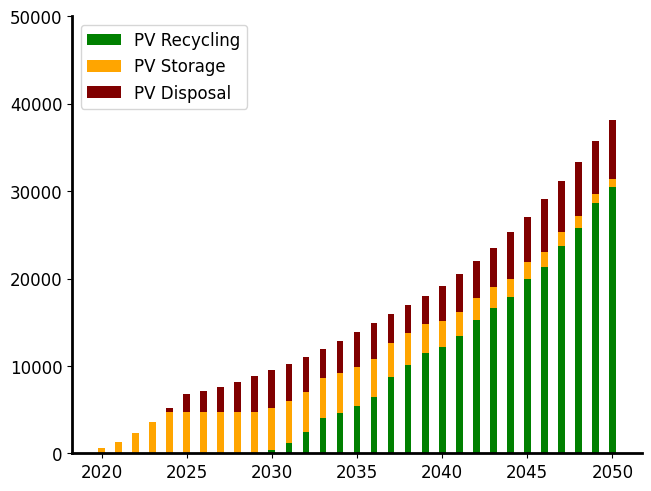

Year 2050 Cumulative PV EoU Management Outcomes:
PV Disposal:28.4%
PV Recovery:71.4%
PV Storage:0.2%
Mass balance check:100.0%


In [6]:
#Parameter change for analysis
lf_cost_pv_test = 100 #usd/ton

#Initialize Model
IS_ABM = PV_EoU_IS(width = boundary_len, height = boundary_len, agent_positions = agent_pos,
                 pv_avl = eou_pv['0'], virgin_material_supply = vir_mat_supply_norm,
                 mfg_firm_demands = demand_proj, initial_exp_dem = expected_demand0,
                 new_mat_costs = v_cost_norm, rec_mat_costs = r_cost_norm, delivery_cost = ship_cost,
                 lf_cost_pv = lf_cost_pv_test, lf_cost_mat = lf_cost_mat,
                 pv_rec_cost = rec_cost_b, req_pv_rec_param = req_pv_rec_unit_mat,
                 pv_firm_inv_vol = usable_inv_vol, req_stor_vol = stor_vol_req, pv_lf_dist = lf_dist,
                 mfg_firms_init_sec_mat_use = sec_material_use0, mfg_firms_max_sec_mat_use = sec_mat_use_limit,
                 mfg_firm_behaviors = opp_behavior_probability,
                 initial_pv_firm_trust = pv_firm_trust_ratings0, mfg_threshold_param = threshold_percentage,
                 num_sim_steps = N_steps)
print('Model initalized')

#Test batch run with PV recovery analysis
batch_results = IS_ABM.run_batch_sim(num_sims = 500)
print('Batch simulation complete')

#Plot and analyze mean PV amounts in different waste management pathways
IS_ABM.PV_waste_management_analysis(batch_results = batch_results)

#Cumulative EoU outcomes
cum_pv_rec, cum_pv_disp, pv_stor = IS_ABM.cumulative_pv_EoU_analysis(batch_results = batch_results)
#Year 2050
print('Year 2050 Cumulative PV EoU Management Outcomes:')
print("PV Disposal:{}%".format(round(cum_pv_disp[30], 1)))
print("PV Recovery:{}%".format(round(cum_pv_rec[30], 1)))
print("PV Storage:{}%".format(round(pv_stor[30], 1)))
print("Mass balance check:{}%".format(round(cum_pv_disp[30]+cum_pv_rec[30]+pv_stor[30], 1)))
#Year 2030
#print('Year 2030 Cumulative PV EoU Management Outcomes:')
#print("PV Disposal:{}%".format(round(cum_pv_disp[10], 1)))
#print("PV Recovery:{}%".format(round(cum_pv_rec[10], 1)))
#print("PV Storage:{}%".format(round(pv_stor[10], 1)))
#print("Mass balance check:{}%".format(round(cum_pv_disp[10]+cum_pv_rec[10]+pv_stor[10], 1)))
#Year 2035
#print('Year 2035 Cumulative PV EoU Management Outcomes:')
#print("PV Disposal:{}%".format(round(cum_pv_disp[15], 1)))
#print("PV Recovery:{}%".format(round(cum_pv_rec[15], 1)))
#print("PV Storage:{}%".format(round(pv_stor[15], 1)))
#print("Mass balance check:{}%".format(round(cum_pv_disp[15]+cum_pv_rec[15]+pv_stor[15], 1)))
#Year 2040
#print('Year 2040 Cumulative PV EoU Management Outcomes:')
#print("PV Disposal:{}%".format(round(cum_pv_disp[20], 1)))
#print("PV Recovery:{}%".format(round(cum_pv_rec[20], 1)))
#print("PV Storage:{}%".format(round(pv_stor[20], 1)))
#print("Mass balance check:{}%".format(round(cum_pv_disp[20]+cum_pv_rec[20]+pv_stor[20], 1)))

**Partner Firms Net Economic Benefit Analysis**

In [ ]:
#select firm
f = 'Al'
#Economic benefits
cum_neb = IS_ABM.regional_firm_econ_benefit_analysis(firm = f, batch_results = batch_results)
#Year 2050
print('Year 2050 Cumulative Savings:')
print(cum_neb[30])

**Partner Firms Secondary Material Use Analysis**

In [ ]:
#select firm
f = 'Al'
#Cumulative secondary vs. virgin material use
smu_per, nmu_per = IS_ABM.secondary_mat_use_analysis(firm = f, batch_results = batch_results)

print('Cumulative secondary material use:')
print(smu_per)

**Life Cycle (Avoided) Impact Metrics**

In [ ]:
avoided_impacts = IS_ABM.environmental_impact_analysis(batch_results = batch_results)
print('Cumulative avoided environmental impacts till 2050 (compared to disposing all EoU PVs):')
print(avoided_impacts)

**Partner Firm Exit Analysis**

In [ ]:
#Select firm for disruption test
f = 'Ag'
#Select year of disruption
t = 15

#Demand cut to simulate disruption
demand_proj_firm_dis = copy.deepcopy(demand_proj)
for i in range(t,N_steps):
    demand_proj_firm_dis[f][i] = 0

#Initialize Model
IS_ABM_f_exit = PV_EoU_IS(width = boundary_len, height = boundary_len, agent_positions = agent_pos,
                 pv_avl = eou_pv['0'], virgin_material_supply = vir_mat_supply_norm,
                 mfg_firm_demands = demand_proj_firm_dis, initial_exp_dem = expected_demand0,
                 new_mat_costs = v_cost_norm, rec_mat_costs = r_cost_norm, delivery_cost = ship_cost,
                 lf_cost_pv = lf_cost_pv_test, lf_cost_mat = lf_cost_mat,
                 pv_rec_cost = rec_cost_b, req_pv_rec_param = req_pv_rec_unit_mat,
                 pv_firm_inv_vol = usable_inv_vol, req_stor_vol = stor_vol_req, pv_lf_dist = lf_dist,
                 mfg_firms_init_sec_mat_use = sec_material_use0, mfg_firms_max_sec_mat_use = sec_mat_use_limit,
                 mfg_firm_behaviors = opp_behavior_probability,
                 initial_pv_firm_trust = pv_firm_trust_ratings0, mfg_threshold_param = threshold_percentage,
                 num_sim_steps = N_steps)
print('Model initalized')

#Test batch run with PV recovery analysis
batch_results = IS_ABM_f_exit.run_batch_sim(num_sims = 500)
print('Batch simulation complete')

#Plot and analyze mean PV amounts in different waste management pathways
IS_ABM_f_exit.PV_waste_management_analysis(batch_results = batch_results)

#Cumulative EoU outcomes
cum_pv_rec, cum_pv_disp, pv_stor = IS_ABM_f_exit.cumulative_pv_EoU_analysis(batch_results = batch_results)
#Year 2050
print('Year 2050 Cumulative PV EoU Management Outcomes:')
print("PV Disposal:{}%".format(round(cum_pv_disp[30], 1)))
print("PV Recovery:{}%".format(round(cum_pv_rec[30], 1)))
print("PV Storage:{}%".format(round(pv_stor[30], 1)))
print("Mass balance check:{}%".format(round(cum_pv_disp[30]+cum_pv_rec[30]+pv_stor[30], 1)))
#Year 2030
#print('Year 2030 Cumulative PV EoU Management Outcomes:')
#print("PV Disposal:{}%".format(round(cum_pv_disp[10], 1)))
#print("PV Recovery:{}%".format(round(cum_pv_rec[10], 1)))
#print("PV Storage:{}%".format(round(pv_stor[10], 1)))
#print("Mass balance check:{}%".format(round(cum_pv_disp[10]+cum_pv_rec[10]+pv_stor[10], 1)))
#Year 2035
#print('Year 2035 Cumulative PV EoU Management Outcomes:')
#print("PV Disposal:{}%".format(round(cum_pv_disp[15], 1)))
#print("PV Recovery:{}%".format(round(cum_pv_rec[15], 1)))
#print("PV Storage:{}%".format(round(pv_stor[15], 1)))
#print("Mass balance check:{}%".format(round(cum_pv_disp[15]+cum_pv_rec[15]+pv_stor[15], 1)))
#Year 2040
#print('Year 2040 Cumulative PV EoU Management Outcomes:')
#print("PV Disposal:{}%".format(round(cum_pv_disp[20], 1)))
#print("PV Recovery:{}%".format(round(cum_pv_rec[20], 1)))
#print("PV Storage:{}%".format(round(pv_stor[20], 1)))
#print("Mass balance check:{}%".format(round(cum_pv_disp[20]+cum_pv_rec[20]+pv_stor[20], 1)))

**Stability Test**

In [ ]:
#IS_ABM = PV_EoU_IS(width = boundary_len, height = boundary_len, agent_positions = agent_pos,
                 pv_avl = eou_pv['0'], virgin_material_supply = vir_mat_supply_norm,
                 mfg_firm_demands = demand_proj, initial_exp_dem = expected_demand0,
                 new_mat_costs = v_cost_norm, rec_mat_costs = r_cost_norm, delivery_cost = ship_cost,
                 lf_cost_pv = lf_cost_pv, lf_cost_mat = lf_cost_mat,
                 pv_rec_cost = rec_cost_f, req_pv_rec_param = req_pv_rec_unit_mat,
                 pv_firm_inv_vol = usable_inv_vol, req_stor_vol = stor_vol_req, pv_lf_dist = lf_dist,
                 mfg_firms_init_sec_mat_use = sec_material_use0, mfg_firms_max_sec_mat_use = sec_mat_use_limit,
                 mfg_firm_behaviors = opp_behavior_probability,
                 initial_pv_firm_trust = pv_firm_trust_ratings0, mfg_threshold_param = threshold_percentage,
                 num_sim_steps = N_steps)
#print('Test - model initalized')

#mean_2050_pv_rec_amts = IS_ABM.stability_test()

#Save Stability Test Results
#num_sims = np.linspace(1,700,700)
#stability_test_results = {'Number of Repetitions': num_sims,
                          #'Average PV Recovery Amount in 2050': mean_2050_pv_rec_amts}

#stability_test_results = pd.DataFrame(stability_test_results)
#stability_test_results.to_csv('Stability Test.csv', index=False)